# Chicago 311 Service Requests - MongoDB Analiza

**Autor:** Uroš Ogrizović IN12-2022  
**Predmet:** Sistemi baza podataka, FTN Novi Sad  
**Dataset:** Chicago 311 Service Requests (~1.3 GB, 12 CSV fajlova, 4M+ redova)

---

## 1. Imports

In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt
import json
from pprint import pprint

import connection
import load_data
import base_queries
import optimized_queries
import optimize_schema
import query_executor

/home/uros/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 2. MongoDB konekcija

In [2]:
MONGO_URI = "mongodb://localhost:27017/"
MONGO_DATABASE_NAME = "chicago_311_db"

client, database = connection.connect_to_mongodb(MONGO_URI, MONGO_DATABASE_NAME)

Povezan na MongoDB: mongodb://localhost:27017/
Baza podataka: chicago_311_db


## 3. Učitavanje podataka

Učitavanje 12 CSV fajlova u 6 normalizovanih kolekcija:
- `requests` - zajednička polja svih zahteva
- `locations` - deduplikovani geografski podaci
- `vehicle_details` - detalji napuštenih vozila
- `sanitation_details` - sanitarni detalji (glodari, đubre, kodne povrede)
- `environment_details` - infrastruktura i okruženje (rupe, svetla, grafiti, drveće)
- `building_details` - detalji napuštenih zgrada

In [ ]:
load_data.drop_all_collections(database)
stats = load_data.load_all_data(database)

### Pregled broja dokumenata po kolekciji

In [3]:
print("Broj dokumenata po kolekciji:")
print("=" * 40)
for coll_name in ["requests", "locations", "vehicle_details",
                   "sanitation_details", "environment_details", "building_details"]:
    count = database[coll_name].count_documents({})
    print(f"  {coll_name}: {count:,}")

print(f"\nPrimer dokumenta iz 'requests':")
pprint(database["requests"].find_one())

print(f"\nPrimer dokumenta iz 'locations':")
pprint(database["locations"].find_one())

Broj dokumenata po kolekciji:
  requests: 4,329,643
  locations: 934,715
  vehicle_details: 242,734
  sanitation_details: 875,642
  environment_details: 3,146,148
  building_details: 65,119

Primer dokumenta iz 'requests':
{'_id': ObjectId('6a4023dce31ca7dbe84aa1b2'),
 'completion_date': datetime.datetime(2015, 4, 9, 0, 0),
 'creation_date': datetime.datetime(2015, 4, 8, 0, 0),
 'current_activity': 'FVI - Outcome',
 'location_id': ObjectId('6a4023dce31ca7dbe84aa1b1'),
 'most_recent_action': 'Vehicle was moved from original address requested',
 'request_type': 'Abandoned Vehicle Complaint',
 'service_request_number': '15-01207496',
 'status': 'Completed'}

Primer dokumenta iz 'locations':
{'_id': ObjectId('6a4023dce31ca7dbe84aa1b1'),
 'community_area': 6,
 'latitude': 41.93702589972641,
 'longitude': -87.64615132728282,
 'police_district': 19,
 'street_address': '3020 N WATERLOO CT',
 'ward': 44,
 'zip_code': '60657'}


## 4. Kreiranje indeksa za inicijalnu šemu

In [6]:
load_data.create_base_indexes(database)

Kreiranje indeksa za base shemu...
Indeksi kreirani uspesno.


### Pregled kreiranih indeksa

In [7]:
for coll_name in ["requests", "locations", "vehicle_details",
                   "sanitation_details", "environment_details", "building_details"]:
    indexes = database[coll_name].index_information()
    print(f"\n{coll_name}:")
    for idx_name, idx_info in indexes.items():
        print(f"  {idx_name}: {idx_info['key']}")


requests:
  _id_: [('_id', 1)]
  request_type_1: [('request_type', 1)]
  creation_date_1: [('creation_date', 1)]
  status_1: [('status', 1)]
  location_id_1: [('location_id', 1)]
  service_request_number_1: [('service_request_number', 1)]

locations:
  _id_: [('_id', 1)]
  ward_1: [('ward', 1)]
  community_area_1: [('community_area', 1)]
  police_district_1: [('police_district', 1)]
  zip_code_1: [('zip_code', 1)]
  street_address_1: [('street_address', 1)]

vehicle_details:
  _id_: [('_id', 1)]
  request_id_1: [('request_id', 1)]
  days_parked_1: [('days_parked', 1)]

sanitation_details:
  _id_: [('_id', 1)]
  request_id_1: [('request_id', 1)]
  sub_type_1: [('sub_type', 1)]

environment_details:
  _id_: [('_id', 1)]
  request_id_1: [('request_id', 1)]
  sub_type_1: [('sub_type', 1)]

building_details:
  _id_: [('_id', 1)]
  request_id_1: [('request_id', 1)]
  is_dangerous_1: [('is_dangerous', 1)]


## 5. Analiza upita — inicijalna (normalizovana) šema

Aggregation pipeline-ovi koji koriste `$lookup` za spajanje kolekcija.

---

### Q6: Glodari po community area

Koje community areas imaju najviše prijava za glodare i koliko je prosečno zaraženih objekata po prijavi?

In [4]:
pipeline = base_queries.query_6_rodent_community()
results_q6, time_q6 = query_executor.execute_query(
    database["requests"], pipeline, "Q6 - Glodari po community area")

df = pd.DataFrame(results_q6)
print(df.to_string(index=False))

Q6 - Glodari po community area: 507.325s (15 rezultata)
 complaint_count  total_premises_with_rats  total_premises_baited  community_area
           15704                     42446                  32812               6
           15614                     47669                  52775              22
           15086                     43038                  34859               2
           14320                     44106                  37688              24
           12522                     31601                  26055               7
           11194                     29200                  20180              25
           10518                     21877                  16504              16
            9149                     17415                  18878              15
            8432                     23342                  18168              19
            8397                     19061                  12770              67
            8074                     25843

### Q7: Napuštena vozila (30+ dana)

Top 10 ward-ova sa napuštenim vozilima parkiranim 30+ dana — koliko ih ima i koliko u proseku stoje?

In [5]:
pipeline = base_queries.query_7_abandoned_vehicles()
results_q7, time_q7 = query_executor.execute_query(
    database["requests"], pipeline, "Q7 - Napuštena vozila (30+ dana)")

df = pd.DataFrame(results_q7)
print(df.to_string(index=False))

Q7 - Napuštena vozila (30+ dana): 512.544s (10 rezultata)
 vehicle_count    max_days_parked  ward  avg_days_parked
          3198            1000000    45     4.703000e+02
          2867             605887    38     2.673000e+02
          2827               1460    36     6.110000e+01
          2730               1826    13     5.900000e+01
          2567             122510    11     1.590000e+02
          2389            6676478    39     2.858800e+03
          2380              99999    14     9.910000e+01
          2366 100000000000000000    37     4.230769e+13
          2281              99999    35     1.097000e+02
          2245             302742    32     2.000000e+02


### Q8: Sezonski obrazac glodara

Prosečan mesečni broj prijava za glodare (preko svih godina). Koji meseci su najgori?

Koristi dupli `$group`: prvo po (godina, mesec), pa po mesecu za prosek.

In [6]:
pipeline = base_queries.query_8_rodent_seasonal()
results_q8, time_q8 = query_executor.execute_query(
    database["requests"], pipeline, "Q8 - Sezonski obrazac glodara")

df = pd.DataFrame(results_q8)
print(df.to_string(index=False))

Q8 - Sezonski obrazac glodara: 253.659s (12 rezultata)
 min_complaints  max_complaints  month  avg_complaints
              1            2814      1          1487.4
            676            2577      2          1515.1
           1682            3503      3          2490.2
           2387            4341      4          2937.1
           2705            4251      5          3440.9
              1            5316      6          3626.2
              2            6094      7          4010.3
              6            7019      8          4741.3
              8            5610      9          4124.3
             27            5627     10          3790.7
              1            4542     11          2184.4
            121            2339     12          1582.6


### Q9: Neresolvane sanitarne žalbe

Koje community areas imaju najviše neresolvanih sanitarnih žalbi i koji je procenat neresolvanih?

In [7]:
pipeline = base_queries.query_9_unresolved_sanitation()
results_q9, time_q9 = query_executor.execute_query(
    database["requests"], pipeline, "Q9 - Neresolvane sanitarne žalbe")

df = pd.DataFrame(results_q9)
print(df.to_string(index=False))

Q9 - Neresolvane sanitarne žalbe: 477.925s (15 rezultata)
 total_complaints  unresolved_count  unresolved_pct  community_area
            41305              5489            13.3              25
            25218              3389            13.4              71
            22702              3157            13.9              66
            25553              3104            12.1              23
            30484              2911             9.5              24
            24312              2822            11.6              67
            18519              2708            14.6              29
            22510              2553            11.3              15
            30480              2540             8.3              22
            26541              2518             9.5               2
            21384              2478            11.6              16
            19792              2452            12.4              49
            22700              2375            10.5       

### Q10: Opasne zgrade po community area

Gde ima najviše opasnih zgrada, otvorenih zgrada, i zgrada gde ljudi koriste imovinu?

In [8]:
pipeline = base_queries.query_10_dangerous_buildings()
results_q10, time_q10 = query_executor.execute_query(
    database["requests"], pipeline, "Q10 - Opasne zgrade po community area")

df = pd.DataFrame(results_q10)
print(df.to_string(index=False))

Q10 - Opasne zgrade po community area: 466.834s (15 rezultata)
 total_buildings  dangerous_count  open_count  people_using_count  community_area
             376                0         276                 130            47.0
            4292                0        3440                1567            68.0
             221                0         158                 104            35.0
            3692                0        2823                1468            49.0
             188                0         147                  80            57.0
             575                0         456                 298            58.0
            2336                0        1831                1186            23.0
              33                0          10                   4             NaN
             191                0         138                  67            59.0
             614                0         441                 244            38.0
               9                0  

### Sačuvaj vremena izvršavanja base upita

In [9]:
base_times = {
    "Q6": time_q6, "Q7": time_q7, "Q8": time_q8, "Q9": time_q9, "Q10": time_q10
}

print("\nVremena izvršavanja (base šema):")
print("=" * 40)
for name, t in base_times.items():
    print(f"  {name}: {t:.3f}s")


Vremena izvršavanja (base šema):
  Q6: 507.325s
  Q7: 512.544s
  Q8: 253.659s
  Q9: 477.925s
  Q10: 466.834s


## 6. Optimizacija šeme

Migracija 6 normalizovanih kolekcija → 1 kolekcija sa embedded dokumentima.  
Koristi cache pristup: učita sve lookup podatke u memoriju, pa gradi nove dokumente.

In [15]:
optimize_schema.migrate_to_embedded(database)

Pocetak migracije u embedded shemu...
  Ucitavanje locations u memoriju...


  locations: 100%|███████████████████████████████████████████████████████████████████████████████████████| 934715/934715 [00:04<00:00, 196509.37it/s]


  Ucitavanje vehicle_details u memoriju...


  vehicle_details: 100%|█████████████████████████████████████████████████████████████████████████████████| 242734/242734 [00:01<00:00, 123812.86it/s]


  Ucitavanje sanitation_details u memoriju...


...

  building_details: 100%|██████████████████████████████████████████████████████████████████████████████████| 65119/65119 [00:00<00:00, 161323.20it/s]


  Gradnja embedded dokumenata...


  requests: 100%|███████████████████████████████████████████████████████████████████████████████████████| 4329643/4329643 [02:00<00:00, 35935.84it/s]



Migracija zavrsena: 4,329,643 dokumenata u 'requests_optimized'


4329643

In [16]:
optimize_schema.create_optimized_indexes(database)

Kreiranje indeksa za optimizovanu shemu...
Indeksi za optimizovanu shemu kreirani.


In [10]:
print(f"Broj dokumenata u optimizovanoj kolekciji: {database['requests_optimized'].count_documents({}):,}")
print(f"\nPrimer embedded dokumenta:")
pprint(database["requests_optimized"].find_one())

Broj dokumenata u optimizovanoj kolekciji: 4,329,643

Primer embedded dokumenta:
{'_id': ObjectId('6a480bafd4b54de5b3a0e80b'),
 'completion_date': datetime.datetime(2015, 4, 9, 0, 0),
 'creation_date': datetime.datetime(2015, 4, 8, 0, 0),
 'current_activity': 'FVI - Outcome',
 'details': {'days_parked': 90,
             'license_plate': 'S48 3272',
             'vehicle_color': 'Silver',
             'vehicle_make_model': 'Bmw'},
 'location': {'community_area': 6,
              'latitude': 41.93702589972641,
              'longitude': -87.64615132728282,
              'police_district': 19,
              'street_address': '3020 N WATERLOO CT',
              'ward': 44,
              'zip_code': '60657'},
 'most_recent_action': 'Vehicle was moved from original address requested',
 'request_type': 'Abandoned Vehicle Complaint',
 'service_request_number': '15-01207496',
 'status': 'Completed'}


### Pregled indeksa optimizovane kolekcije

In [11]:
indexes = database["requests_optimized"].index_information()
print("Indeksi na 'requests_optimized':")
for idx_name, idx_info in indexes.items():
    print(f"  {idx_name}: {idx_info['key']}")

Indeksi na 'requests_optimized':
  _id_: [('_id', 1)]
  request_type_1_location.ward_1: [('request_type', 1), ('location.ward', 1)]
  location.community_area_1_request_type_1: [('location.community_area', 1), ('request_type', 1)]
  creation_date_1_request_type_1: [('creation_date', 1), ('request_type', 1)]
  status_1: [('status', 1)]
  location.police_district_1: [('location.police_district', 1)]
  location.street_address_1: [('location.street_address', 1)]
  details.sub_type_1: [('details.sub_type', 1)]
  details.days_parked_1: [('details.days_parked', 1)]
  details.is_dangerous_1: [('details.is_dangerous', 1)]
  location.zip_code_1: [('location.zip_code', 1)]


## 7. Optimizovani upiti (embedded šema, bez $lookup)

Istih 5 pitanja, prepisani za embedded šemu. Bez `$lookup` operacija.

---

### Q6 (optimizovano): Glodari po community area

In [12]:
pipeline = optimized_queries.query_6_rodent_community()
opt_results_q6, opt_time_q6 = query_executor.execute_query(
    database["requests_optimized"], pipeline, "Q6-opt")

df = pd.DataFrame(opt_results_q6)
print(df.to_string(index=False))

Q6-opt: 0.914s (15 rezultata)
 complaint_count  total_premises_with_rats  total_premises_baited  community_area
           15704                     42446                  32812               6
           15614                     47669                  52775              22
           15086                     43038                  34859               2
           14320                     44106                  37688              24
           12522                     31601                  26055               7
           11194                     29200                  20180              25
           10518                     21877                  16504              16
            9149                     17415                  18878              15
            8432                     23342                  18168              19
            8397                     19061                  12770              67
            8074                     25843                  18487   

### Q7 (optimizovano): Napuštena vozila (30+ dana)

In [13]:
pipeline = optimized_queries.query_7_abandoned_vehicles()
opt_results_q7, opt_time_q7 = query_executor.execute_query(
    database["requests_optimized"], pipeline, "Q7-opt")

df = pd.DataFrame(opt_results_q7)
print(df.to_string(index=False))

Q7-opt: 0.344s (10 rezultata)
 vehicle_count    max_days_parked  ward  avg_days_parked
          3198            1000000    45     4.703000e+02
          2867             605887    38     2.673000e+02
          2827               1460    36     6.110000e+01
          2730               1826    13     5.900000e+01
          2567             122510    11     1.590000e+02
          2389            6676478    39     2.858800e+03
          2380              99999    14     9.910000e+01
          2366 100000000000000000    37     4.230769e+13
          2281              99999    35     1.097000e+02
          2245             302742    32     2.000000e+02


### Q8 (optimizovano): Sezonski obrazac glodara

In [14]:
pipeline = optimized_queries.query_8_rodent_seasonal()
opt_results_q8, opt_time_q8 = query_executor.execute_query(
    database["requests_optimized"], pipeline, "Q8-opt")

df = pd.DataFrame(opt_results_q8)
print(df.to_string(index=False))

Q8-opt: 0.653s (12 rezultata)
 min_complaints  max_complaints  month  avg_complaints
              1            2814      1          1487.4
            676            2577      2          1515.1
           1682            3503      3          2490.2
           2387            4341      4          2937.1
           2705            4251      5          3440.9
              1            5316      6          3626.2
              2            6094      7          4010.3
              6            7019      8          4741.3
              8            5610      9          4124.3
             27            5627     10          3790.7
              1            4542     11          2184.4
            121            2339     12          1582.6


### Q9 (optimizovano): Neresolvane sanitarne žalbe

In [15]:
pipeline = optimized_queries.query_9_unresolved_sanitation()
opt_results_q9, opt_time_q9 = query_executor.execute_query(
    database["requests_optimized"], pipeline, "Q9-opt")

df = pd.DataFrame(opt_results_q9)
print(df.to_string(index=False))

Q9-opt: 1.972s (15 rezultata)
 total_complaints  unresolved_count  unresolved_pct  community_area
            41305              5489            13.3              25
            25218              3389            13.4              71
            22702              3157            13.9              66
            25553              3104            12.1              23
            30484              2911             9.5              24
            24312              2822            11.6              67
            18519              2708            14.6              29
            22510              2553            11.3              15
            30480              2540             8.3              22
            26541              2518             9.5               2
            21384              2478            11.6              16
            19792              2452            12.4              49
            22700              2375            10.5              19
            18341 

### Q10 (optimizovano): Opasne zgrade po community area

In [16]:
pipeline = optimized_queries.query_10_dangerous_buildings()
opt_results_q10, opt_time_q10 = query_executor.execute_query(
    database["requests_optimized"], pipeline, "Q10-opt")

df = pd.DataFrame(opt_results_q10)
print(df.to_string(index=False))

Q10-opt: 0.248s (15 rezultata)
 total_buildings  dangerous_count  open_count  people_using_count  community_area
             772                0         538                 274              75
            1296                0         935                 535              42
            1194                0         887                 467              73
             653                0         482                 222              51
             177                0         112                  40               6
             330                0         221                  96              16
            2003                0        1485                 802              43
            6104                0        4882                2523              67
              68                0          37                  14              41
              11                0           8                   2               0
              31                0          19                   6  

## 8. Uporedna analiza performansi

In [17]:
opt_times = {
    "Q6": opt_time_q6, "Q7": opt_time_q7, "Q8": opt_time_q8,
    "Q9": opt_time_q9, "Q10": opt_time_q10
}

comparison = []
for q in ["Q6", "Q7", "Q8", "Q9", "Q10"]:
    bt = base_times[q]
    ot = opt_times[q]
    improvement = ((bt - ot) / bt) * 100 if bt > 0 else 0
    comparison.append({
        "Upit": q,
        "Base (s)": round(bt, 3),
        "Optimized (s)": round(ot, 3),
        "Ubrzanje (%)": round(improvement, 1)
    })

df_comp = pd.DataFrame(comparison)
print(df_comp.to_string(index=False))

avg_improvement = df_comp["Ubrzanje (%)"].mean()
print(f"\nProsečno ubrzanje: {avg_improvement:.1f}%")

Upit  Base (s)  Optimized (s)  Ubrzanje (%)
  Q6   507.325          0.914          99.8
  Q7   512.544          0.344          99.9
  Q8   253.659          0.653          99.7
  Q9   477.925          1.972          99.6
 Q10   466.834          0.248          99.9

Prosečno ubrzanje: 99.8%


### Grafički prikaz poređenja

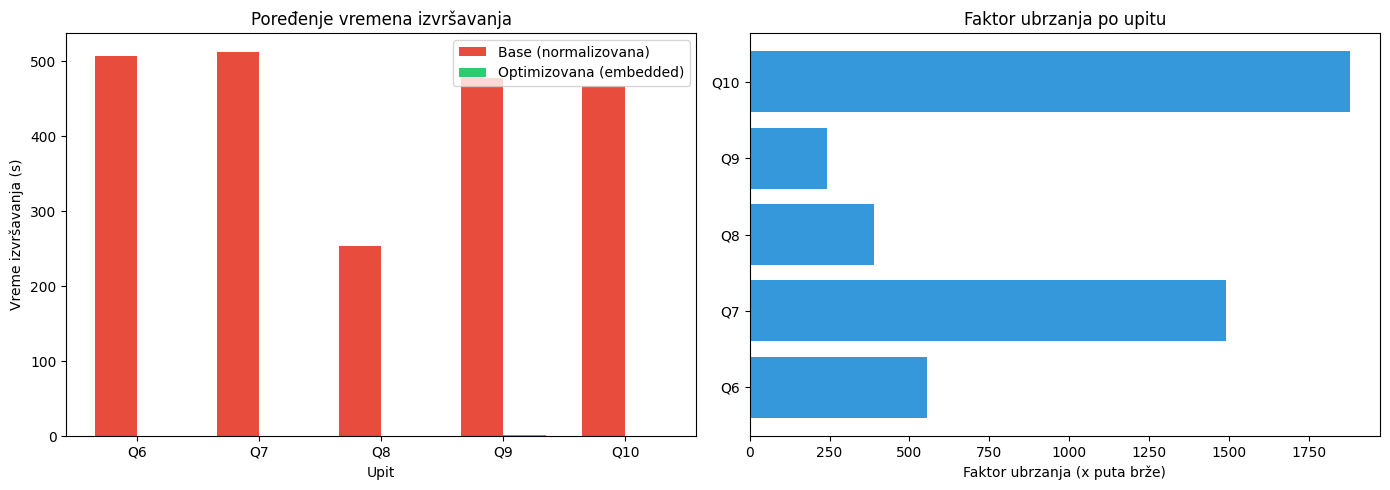

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

queries = list(base_times.keys())
base_vals = [base_times[q] for q in queries]
opt_vals = [opt_times[q] for q in queries]

x = range(len(queries))
width = 0.35

axes[0].bar([i - width/2 for i in x], base_vals, width, label='Base (normalizovana)', color='#e74c3c')
axes[0].bar([i + width/2 for i in x], opt_vals, width, label='Optimizovana (embedded)', color='#2ecc71')
axes[0].set_xlabel('Upit')
axes[0].set_ylabel('Vreme izvršavanja (s)')
axes[0].set_title('Poređenje vremena izvršavanja')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(queries)
axes[0].legend()

speedups = [base_times[q] / opt_times[q] if opt_times[q] > 0 else 0 for q in queries]
axes[1].barh(queries, speedups, color='#3498db')
axes[1].set_xlabel('Faktor ubrzanja (x puta brže)')
axes[1].set_title('Faktor ubrzanja po upitu')

plt.tight_layout()
plt.savefig("performance_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

### Explain analiza

In [19]:
import json

def analyze_explain(collection_name, pipeline, label):
    explain = database.command("aggregate", collection_name,
        pipeline=pipeline, explain=True, allowDiskUse=True)

    print(f"\n{'=' * 60}")
    print(f"EXPLAIN: {label}")
    print(f"{'=' * 60}")

    stages = explain.get("stages", [])
    if stages:
        first = stages[0]
        cursor = first.get("$cursor", {})
        query_planner = cursor.get("queryPlanner", {})
        winning = query_planner.get("winningPlan", {})

        stage = winning.get("stage", "N/A")
        input_stage = winning.get("inputStage", {})
        index_name = input_stage.get("indexName", "N/A")

        print(f"  Winning plan stage: {stage}")
        if stage == "IXSCAN" or input_stage.get("stage") == "IXSCAN":
            print(f"  Index: {index_name}")
        elif stage == "COLLSCAN":
            print(f"  UPOZORENJE: Collection scan (nema indeksa)")
    else:
        print(json.dumps(explain, indent=2, default=str)[:500])

analyze_explain("requests",
    base_queries.query_6_rodent_community(),
    "Q6 Base (normalizovana)")
analyze_explain("requests_optimized",
    optimized_queries.query_6_rodent_community(),
    "Q6 Optimizovana (embedded)")


EXPLAIN: Q6 Base (normalizovana)
  Winning plan stage: PROJECTION_SIMPLE

EXPLAIN: Q6 Optimizovana (embedded)
  Winning plan stage: PROJECTION_DEFAULT


## Zaključak

Analiza Q6-Q10 pokriva javno zdravlje i bezbednost u Čikagu:

1. **Q6** — Identifikacija community areas sa najvećim problemom glodara
2. **Q7** — Ward-ovi sa vozilima koja stoje 30+ dana
3. **Q8** — Sezonski obrasci prijava za glodare (dupli group za mesečni prosek)
4. **Q9** — Community areas sa najviše neresolvanih sanitarnih žalbi
5. **Q10** — Lokacije sa opasnim zgradama

Optimizacijom šeme (embedding + compound indeksi) eliminisani su `$lookup` operatori, što je rezultovalo značajnim ubrzanjem svih upita.